In [1]:
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
import librosa
import torch
import pandas as pd
import torch.nn as nn 
import torch.optim as optim 
import numpy as np
from torch.utils.data import DataLoader, Dataset, random_split

In [ ]:
TARGET_SAMPLES = 30800
TARGET_SAMPLING_RATE = 31250

def wav_to_spectrogram(path: str) -> np.ndarray:
    arr, _ = librosa.load(path=path, sr=TARGET_SAMPLING_RATE, mono=True)
    arr = librosa.util.fix_length(arr, size=TARGET_SAMPLES)
    S = librosa.feature.melspectrogram(y=arr, sr=TARGET_SAMPLING_RATE, n_mels=64)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db


def batch(input_dir : str, output_dir : str):
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    for wav_file in input_path.rglob("*.wav"):
        spec = wav_to_spectrogram(str(wav_file))
        
        spec_tensor = torch.from_numpy(spec).unsqueeze(0)

        out_file = output_path / (wav_file.stem + ".pt")

        torch.save(spec_tensor, out_file)

    print(f'Done {input_dir}')


def wav_to_pcm(path: str) -> np.ndarray :
    
    arr, _ = librosa.load(path=path, sr=TARGET_SAMPLING_RATE, mono=True)

    # pad it to make sure it matches the length of our user audio sample
    if len(arr) < TARGET_SAMPLES:
        arr = np.pad(arr, (TARGET_SAMPLES-len(arr), 0))
    else:
        arr = arr[:TARGET_SAMPLES]

    arr_int16 = (arr*32767).astype(np.int16)

    return arr_int16

def batch(input_dir : str, output_dir : str):
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    for wav_file in input_path.rglob("*.wav"):
        pcm_array = wav_to_pcm(str(wav_file))
        
        out_file = output_path / (wav_file.stem + ".txt") #extracts only the name
        # pcm_array.tofile(str(out_file))
        np.savetxt(str(out_file), pcm_array, fmt='%d')

    print(f'Done {input_dir}')


batch(r"VoiceRecognitionDataset\one",r"Voice Recognition as .txt\one")
batch(r"VoiceRecognitionDataset\two",r"Voice Recognition as .txt\two")
batch(r"VoiceRecognitionDataset\three",r"Voice Recognition as .txt\three")
batch(r"VoiceRecognitionDataset\four",r"Voice Recognition as .txt\four")
batch(r"VoiceRecognitionDataset\five",r"Voice Recognition as .txt\five")
batch(r"VoiceRecognitionDataset\six",r"Voice Recognition as .txt\six")
batch(r"VoiceRecognitionDataset\seven",r"Voice Recognition as .txt\seven")
batch(r"VoiceRecognitionDataset\eight",r"Voice Recognition as .txt\eight")
batch(r"VoiceRecognitionDataset\nine",r"Voice Recognition as .txt\nine")











In [84]:
from tqdm import tqdm

data_info = pd.read_excel("CNN_One_To_Nine.xlsx")


for idx in tqdm(range(len(data_info))):
    folder = data_info.iloc[idx]["Folder Path"]
    name = data_info.iloc[idx]["Name"]

    txt_path = Path(folder) / name

    pt_path = txt_path.with_suffix('.pt')

    if not pt_path.exists():
        sequence = np.loadtxt(txt_path).astype(np.float32)
        sequence_tensor = torch.from_numpy(sequence).unsqueeze(0)

        torch.save(sequence_tensor, pt_path)



100%|██████████| 34856/34856 [00:03<00:00, 10009.06it/s]


In [ ]:
label_map = {
    "one": 0, "two": 1, "three": 2, "four": 3, "five": 4,
    "six": 5, "seven": 6, "eight": 7, "nine": 8, "zero": 9
}


class AudioTextDataset(Dataset):
    def __init__(self, excel_file):
        self.data_info = pd.read_excel(excel_file)
    def __len__(self):
        return len(self.data_info)
    def __getitem__(self,idx):
        Folder = self.data_info.iloc[idx]["Folder Path"]
        Name = Path(self.data_info.iloc[idx]["Name"]).with_suffix('.pt').name
        Class = self.data_info.iloc[idx]["Class"]

        file_path = Path(Folder) / Name

        sequence_tensor = torch.load(file_path, weights_only=True)
        label_tensor = torch.tensor(label_map[Class], dtype=torch.long)

        return sequence_tensor, label_tensor

# The subset percentage was used initially to see if my model would have promising results
# By setting the subset_percentage = 0.1 I can have a general idea how well my model will perform
# while being efficient with time

dataset = AudioTextDataset("One_to_Nine_pt.xlsx")

subset_percentage = 1
use_size = int(subset_percentage * len(dataset))
discard_size = len(dataset)-use_size

main_subset, _ = random_split(dataset, [use_size, discard_size])

total_size = len(main_subset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(main_subset, [train_size, val_size, test_size])

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)



38746
27122
5811
5813
848
182
182


31250


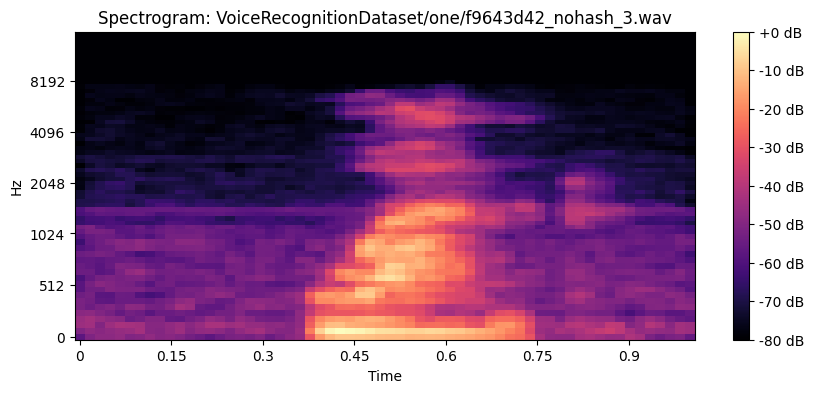

In [ ]:

def visualize_dataset_file(file_path):
    y, sr = librosa.load(file_path, sr=31250)
    print(sr)
    
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    plt.figure(figsize=(10, 4))
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f'Spectrogram: {file_path}')
    plt.show()

# Example usage:
visualize_dataset_file("VoiceRecognitionDataset/one/f9643d42_nohash_3.wav")

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,stride = 1, padding=1, dilation=2), #30800 --> 7700
            nn.BatchNorm2d(16),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.1)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=16,out_channels=16,kernel_size=3,padding=1, groups=16),
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.1)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(in_channels=32,out_channels=32,kernel_size=3,padding=1, groups=32),
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.LeakyReLU(),
            nn.Dropout(0.25),
            nn.Linear(32, 9)
        )

    def forward(self, x):    
        # x = x.unsqueeze(1)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.classifier(x)
        return x



In [91]:
# model = CNN()
model = CNN().to(memory_format=torch.channels_last)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay=0.001)


Epoch 1: Training loss was 1.51, Validation loss was 0.99
Epoch 1: Training accuracy was 0.45, Validation accuracy was 0.64
Epoch 2: Training loss was 0.85, Validation loss was 0.58
Epoch 2: Training accuracy was 0.71, Validation accuracy was 0.81
Epoch 3: Training loss was 0.62, Validation loss was 0.42
Epoch 3: Training accuracy was 0.79, Validation accuracy was 0.87
Epoch 4: Training loss was 0.52, Validation loss was 0.46
Epoch 4: Training accuracy was 0.83, Validation accuracy was 0.85
Epoch 5: Training loss was 0.46, Validation loss was 0.33
Epoch 5: Training accuracy was 0.85, Validation accuracy was 0.90
Epoch 6: Training loss was 0.42, Validation loss was 0.31
Epoch 6: Training accuracy was 0.87, Validation accuracy was 0.91
Epoch 7: Training loss was 0.39, Validation loss was 0.27
Epoch 7: Training accuracy was 0.87, Validation accuracy was 0.91
Epoch 8: Training loss was 0.38, Validation loss was 0.26
Epoch 8: Training accuracy was 0.88, Validation accuracy was 0.92
Epoch 9:

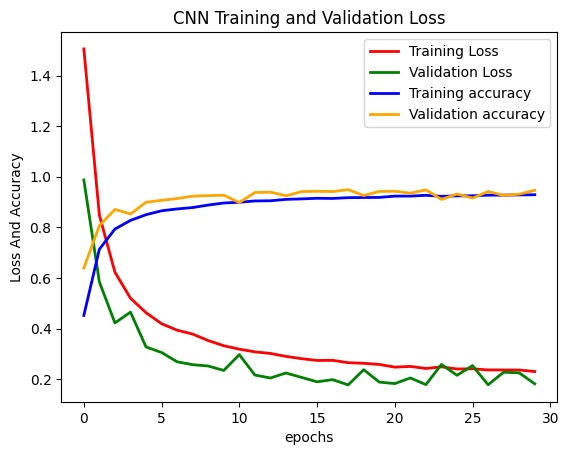

In [94]:
epochs = 30
training_loss = []
training_accuracy = []
validation_loss = []
validation_accuracy = []

for epoch in range(epochs):
    # print("training model")
    model.train()
    # print("Model is trained")
    train_loss = 0
    train_accuracy = 0
    train_total = 0
    # batch = 1
    for sequence, label in train_loader:
        # print(f'Batch {batch}')
        # batch += 1
        sequence, label = sequence.to(device), label.to(device)
        optimizer.zero_grad()
        prediction = model(sequence)
        # print(prediction)
        loss = criterion(prediction, label)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        predicted_classes = torch.argmax(prediction, dim=1)
        train_accuracy += (predicted_classes == label).sum().item()
        train_total += label.size(0)

    training_loss.append(train_loss / len(train_loader))
    training_accuracy.append(train_accuracy / train_total)
    model.eval()
    # print("validation stuff")
    val_loss = 0
    val_accuracy = 0
    val_total = 0
    with torch.no_grad():
        for sequence, label in val_loader:
            prediction = model(sequence)
            val_loss += criterion(prediction, label).item()
            
            predicted_classes = torch.argmax(prediction, dim=1)
            val_accuracy += (predicted_classes == label).sum().item()
            val_total += label.size(0)

    
    validation_loss.append(val_loss / len(val_loader))
    validation_accuracy.append(val_accuracy / val_total)
    print(f'Epoch {epoch+1}: Training loss was {(train_loss / len(train_loader)):.2f}, Validation loss was {(val_loss / len(val_loader)):.2f}')
    print(f'Epoch {epoch+1}: Training accuracy was {(train_accuracy / train_total):.2f}, Validation accuracy was {(val_accuracy / val_total):.2f}')

import matplotlib.pyplot as plt

plt.plot(range(epochs), training_loss, label='Training Loss', color='red', linewidth=2)
plt.plot(range(epochs), validation_loss, label='Validation Loss', color='green', linewidth=2)
plt.plot(range(epochs), training_accuracy, label='Training accuracy', color='blue', linewidth=2)
plt.plot(range(epochs), validation_accuracy, label='Validation accuracy', color='orange', linewidth=2)
plt.xlabel('epochs')
plt.ylabel('Loss And Accuracy')
plt.title('CNN Training and Validation Loss')
plt.legend()
plt.show()

In [95]:
test_loss = 0
test_accuracy = 0
test_total = 0

with torch.no_grad():
        for sequence, label in test_loader:
            prediction = model(sequence)
            test_loss += criterion(prediction, label).item()
            
            predicted_classes = torch.argmax(prediction, dim=1)
            test_accuracy += (predicted_classes == label).sum().item()
            test_total += label.size(0)

print(f'Testing Accuracy: {(test_accuracy / test_total):.2f}, Testing Loss: {(test_loss / len(test_loader)):.2f}')

Testing Accuracy: 0.95, Testing Loss: 0.18


In [96]:
torch.save(model.state_dict(), "VoiceRecognition_2.pth")

model_test = CNN()
model_test.load_state_dict(torch.load("VoiceRecognition_2.pth", weights_only=True))
model_test.eval()

test_loss = 0
test_accuracy = 0
test_total = 0

with torch.no_grad():
        for sequence, label in test_loader:
            prediction = model(sequence)
            test_loss += criterion(prediction, label).item()
            
            predicted_classes = torch.argmax(prediction, dim=1)
            test_accuracy += (predicted_classes == label).sum().item()
            test_total += label.size(0)

print(f'Testing Accuracy: {(test_accuracy / test_total):.2f}, Testing Loss: {(test_loss / len(test_loader)):.2f}')

Testing Accuracy: 0.95, Testing Loss: 0.18
